In [1]:
!pip install gymnasium
!pip install numpy
!pip install matplotlib

In [2]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

In [3]:
env = gym.make("CartPole-v1")

print("Action Space:", env.action_space)
print("State Space:", env.observation_space)

Action Space: Discrete(2)
State Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


In [4]:
alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 500

bins = [20, 20, 20, 20]

q_table = np.zeros(bins + [env.action_space.n])

In [5]:
def discretize_state(state):
    upper_bounds = [4.8, 5, 0.418, 5]
    lower_bounds = [-4.8, -5, -0.418, -5]

    ratios = [(state[i] + abs(lower_bounds[i])) /
              (upper_bounds[i] - lower_bounds[i]) for i in range(len(state))]

    new_state = [int(round((bins[i] - 1) * ratios[i])) for i in range(len(state))]
    new_state = [min(bins[i] - 1, max(0, new_state[i])) for i in range(len(state))]

    return tuple(new_state)

In [6]:
rewards = []

for episode in range(episodes):

    state, _ = env.reset()
    state = discretize_state(state)

    total_reward = 0
    done = False

    while not done:

        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        next_state = discretize_state(next_state)

        best_next_action = np.argmax(q_table[next_state])

        q_table[state][action] = q_table[state][action] + alpha * (
            reward + gamma * q_table[next_state][best_next_action] - q_table[state][action]
        )

        state = next_state
        total_reward += reward

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    rewards.append(total_reward)

    if episode % 50 == 0:
        print("Episode:", episode, "Reward:", total_reward)

env.close()

Episode: 0 Reward: 11.0
Episode: 50 Reward: 10.0
Episode: 100 Reward: 10.0
Episode: 150 Reward: 29.0
Episode: 200 Reward: 18.0
Episode: 250 Reward: 12.0
Episode: 300 Reward: 15.0
Episode: 350 Reward: 15.0
Episode: 400 Reward: 20.0
Episode: 450 Reward: 17.0


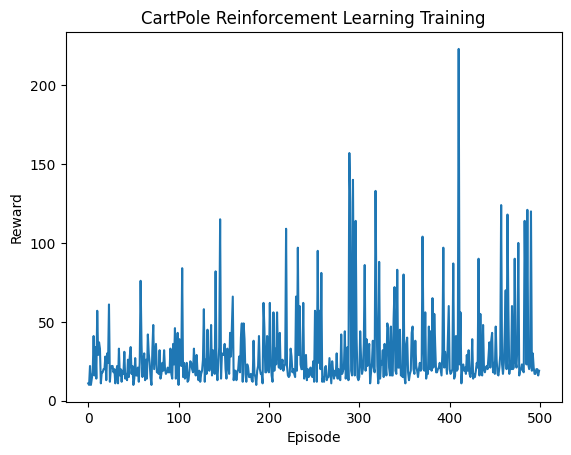

In [7]:
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("CartPole Reinforcement Learning Training")
plt.show()